---
title: Shadow tomography of the Greenberger-Horne-Zeilinger state
description: This tutorial demonstrates the shadow tomography protocol by estimating observables of the Greenberger-Horne-Zeilinger state with up to 100 qubits
---

{/* cspell:ignore matchgate binom bitstr elementwise correlator vmin vmax ests postselects Kueng Zhao Miyake Bertoni Haferkamp Hinsche */}


# Shadow tomography of the Greenberger-Horne-Zeilinger state
*Usage estimate: Under 10 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

## Learning outcomes
After going through this tutorial, users should understand the following:
- How shadow tomography constructs a classical shadow of a quantum state and why it requires exponentially fewer measurements than full state tomography
- How to implement local Pauli shadow tomography using Qiskit to estimate single-qubit magnetizations, two-point correlators, and two-qubit reduced density matrices
- How to use [qiskit-paulice](/docs/addons/qiskit-addon-paulice) for low-overhead error detection using spacetime codes on a large-scale hardware experiment

## Prerequisites
It is recommended that you familiarize yourself with the following topics before going through this tutorial:
- [Measurements](/learning/courses/general-formulation-of-quantum-information/general-measurements)
- [Quantum state tomography](/learning/courses/general-formulation-of-quantum-information/general-measurements/discrimination-and-tomography)
- [Error detection using spacetime codes](/docs/tutorials/ghz-spacetime-codes)

## Background

Full quantum state tomography of an $N$-qubit system requires exponentially many measurements to estimate all $4^N -1$ independent parameters of the density matrix. For a system of 50 qubits, for example, this process requires on the order of $10^{30}$ shots, which is more than a billion times the number of stars in the observable universe. Shadow tomography [\[1\]](#references) is a quantum information protocol that constructs a “classical shadow” of the quantum state, from which target observables can be estimated by using a number of shots that scales logarithmically in the number of observables and is independent of system size $N$, making it relevant across areas in quantum computing, including energy estimation, entanglement entropy and correlation function calculations, kernel estimation in quantum machine learning, and others.

This tutorial shows how to use shadow tomography to estimate local observables, such as the single-qubit magnetization $\langle Z_i \rangle$ for qubit $i$, two-point correlation function $\langle Z_i Z_j\rangle$, and the two-qubit reduced density matrix (2-RDM), of the highly entangled Greenberger-Horne-Zeilinger (GHZ) state. The tutorial first illustrates a small-scale shadow tomography workflow on a 10-qubit GHZ state by using statevector simulation. Then it shows a 100-qubit demonstration on real quantum hardware. This tutorial is recommended for users who are familiar with measurements and quantum state tomography.

### Shadow tomography protocol

The shadow tomography protocol has the following steps:
1. Apply a random unitary $U$, drawn from a unitary ensemble, to the initial quantum state.
2. Measure the outcome in computational basis, obtaining a bitstring $\ket{b}$.
3. Store the classical snapshot, $\hat{\rho} = \mathcal{M}^{-1}(U^{\dagger}\ket{b}\bra{b}U)$, where $\mathcal{M}^{-1}$ is the inverse of the measurement channel $\mathcal{M}(\rho)=\mathbb{E}[U^{\dagger}\ket{b}\bra{b}U]$.
4. Repeat the process $T$ times, where the collection of $T$ snapshots $\{\hat{\rho}_t\}$ makes a classical shadow $S(\rho, T)$.
5. Estimate observable $o$ of operator $O$ as $\frac{1}{T}\sum_{t=1}^{T}\text{Tr}(O\hat{\rho}_t)$.

### Shadow tomography variants

The choice of the unitary ensemble, that is, basis, in step 1 of the protocol, affects the sample complexity, variance of estimates, and information completeness of a given shadow tomography. Many ensemble groups have been considered in the literature, each with unique trade-offs between complexity and efficiency of observable estimation. The properties of the most commonly used variants are summarized in the following table, although this list is not exhaustive.

| Variant | Ensemble | Sample complexity | Circuit depth | Suitable observables |
| ------------ | ---------------------------------| ---------| ---| -------- |
| local Pauli [\[1\]](#references) | single-qubit Paulis $\{X, Y, Z\}$ | $\mathcal{O}(3^k\text{log}M/\varepsilon^2)$ | 1 | local/few-body |
| global Clifford [\[1\]](#references) | $N$-qubit Clifford |$\mathcal{O}(\text{Tr}(O^2)\text{log}M/\varepsilon^2)$ | $\mathcal{O}(N\text{log}N)$ | low-rank, fidelity |
| fermionic Gaussian [\[2\]](#references), [\[3\]](#references)| matchgate circuits | $\mathcal{O}(\binom{\mu}{k}\frac{1}{\varepsilon^2})$  | $\mathcal{O}(N^2)$ | fermionic |
| shallow shadows [\[4\]](#references), [\[5\]](#references) | low-depth circuits| $\mathcal{O}(k2^k\text{log}M/\varepsilon^2)$ | $\mathcal{O}(\text{log}N)$ | non-local (hardware-friendly) |

Here, "sample complexity" refers to the number of measurements needed for a given shadow tomography variant, while "circuit depth" describes how expensive those measurements are to implement on quantum hardware. The terms used in the table are defined as follows: $N$ is the number of qubits, $k$ is the locality of the observable (for example, $\langle Z_i \rangle$ has $k=1$ and $\langle Z_i Z_j\rangle$ has $k=2$), $M$ is the number of observables to be estimated simultaneously, $\varepsilon$ is the additive error tolerance, and $\mu$ is the number of fermions.

Though the local Pauli ensemble is the most hardware-friendly, it pays a $3^k$ sample complexity penalty, which makes it ill-suited for non-local property estimation. More generally, the local-shadow sample-complexity bound scales as $4^k$, improving to $3^k$ in the special case of tensor-product observables. Conversely, while the global Clifford ensemble can be used to estimate non-local observables, its circuit depth is not favorable. Fermionic Gaussian shadows offer utility in simulations of many-body physics, chemistry, and materials, but require matchgate circuits, which might carry significant overhead on general purpose gate-based devices. Shallow shadows sits at a circuit depth between the local Pauli and global Clifford, making it a highly promising variant for practical implementation, though there are still some open questions regarding optimal circuit depth for a given observable.

As the frontier of shadow tomography research continues expanding, some of the most relevant problems to address include optimally choosing the measurement ensemble for a target set of observables, improving sample complexity bounds, and extending the protocol to time-evolved observables. Nonetheless, shadow tomography still presents one of the leading workflows for extracting maximal classical information from a quantum state using a minimum number of measurements, which makes it ideal for characterizing quantum states at scale where both full tomography and classical simulation are impossible.

### The local Pauli ensemble

This tutorial uses the random Pauli basis, that is, single-qubit Clifford gates, to collect shadows and estimate properties of the GHZ state. Note that the Pauli measurements are a great choice for estimating local observables (such as spin density, local correlation functions, and position probability density), but not global ones (such as total energy, momentum, and charge).

Here, a random Pauli basis $\{X, Y, Z\}$ per qubit is independently chosen and the corresponding single-qubit rotation is applied, followed by measurement:

$$

\begin{equation}
U = U_0 \otimes U_1 \otimes \cdots \otimes U_{n-1}, U_q \in \{I, H, S^{\dagger}H\}
\end{equation}
\tag{1}

$$

For this ensemble, the measurement channel's inverse is:

$$

\begin{equation}
\hat{\rho}_q=3U_q^{\dagger}\ket{b_q}\bra{b_q}U_q - I
\end{equation}
\tag{2}
$$

The '3' factor comes from averaging over the three Pauli bases, which produces a depolarizing channel with parameter $\frac{1}{3}$. The full estimator then factorizes as a product of single-qubit estimators. As noted in the table above, it can be seen that for $M$ observables, each of locality $k$, the number of Pauli shadows needed to estimate all observables to additive error $\varepsilon$ with high probability is $\mathcal{O}(\frac{3^k\text{log}(M)}{\varepsilon^2})$. The system size does not affect the measurement cost as long as the observables remain local, so exponentially many observables can be estimated simultaneously with only logarithmic cost.

### Median of means

A plain mean over $T$ snapshots reduces the variance of a single-shot estimate of an observable as $\frac{1}{T}$, but is sensitive to outliers. Median of means can be used to remedy this. The process involves:
- splitting the $T$ snapshots into $K$ equally-sized groups,
- computing the mean within each group,
- returning the median across group means.

This tutorial performs local Pauli shadow tomography to estimate properties of the GHZ state, first using a 10-qubit simulated example and then demonstrating a 100-qubit hardware experiment.

## Requirements
Before starting this tutorial, ensure that you have the following installed:

- Qiskit SDK v2.0 or later, with [visualization](/docs/api/qiskit/visualization) support
- IBM Quantum Compute v0.28 or later (`pip install qiskit-ibm-runtime`)
- Qiskit Paulice (`pip install qiskit-paulice`)

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque, defaultdict
from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.quantum_info import (
    Statevector,
    partial_trace,
    Operator,
    Pauli,
    SparsePauliOp,
)
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_paulice.layout import get_low_overhead_ancillas

In [2]:
seed = 42  # for reproducibility
rng = np.random.default_rng(seed)

The following helper functions are used by the large-scale hardware example later in the tutorial:

- `bad_cz`, `bad_readout`, `bad_coherence` — Query the backend calibration data to identify gates, qubits, and edges that exceed error or coherence thresholds, so they can be excluded from the circuit layout.
- `parallel_ghz` — Builds a GHZ circuit of a given size using a breadth-first search over the coupling map, spreading CNOT layers in parallel to minimize circuit depth.
- `weighted_coverage`, `active_wires`, `z_trace_backward` — Compute how much of the GHZ circuit's error surface is protected by a given set of spacetime parity checks, using the backward-propagation technique from [[6]](#references).
- `add_measurements` — Appends GHZ-qubit and check-qubit measurements into separate classical registers so they can be postselected independently.
- `build_shadow_circuits` — Produces one circuit per random Pauli basis by appending the appropriate single-qubit rotations before measurement.
- `parse_hw_results_w_checks` — Unpacks the Sampler output into `(ghz_bits, check_bits, bases)` triples, one per shot.
- `adapt_to_flat_bits`, `estimate_zz_nn_hw` — Map the GHZ-register bits back into the full-device index space and compute the median-of-means $\langle Z_i Z_{i+1}\rangle$ estimate.

In [3]:
def bad_cz(target, threshold: float = 0.01) -> list:
    "Return edges whose CZ error exceeds threshold."
    edges = []
    for edge in backend.target.build_coupling_map().get_edges():
        if (edge[1], edge[0]) not in edges:
            edges.append(edge)
    cz_errors = {edge: target["cz"][edge].error for edge in edges}
    worst = sorted(cz_errors.items(), key=lambda x: x[1], reverse=True)
    return [list(edge) for edge, error in worst if error > threshold]


def bad_readout(target, threshold: float = 0.01) -> list:
    "Return nodes whose measurement error exceeds threshold."
    meas_errors = {
        node: target["measure"][(node,)].error
        for node in range(backend.num_qubits)
    }
    worst = sorted(meas_errors.items(), key=lambda x: x[1], reverse=True)
    return [node for node, error in worst if error > threshold]


def bad_coherence(target, threshold: float = 60) -> list:
    "Return nodes whose T2 value is below threshold."
    t2s = {
        node: (target.qubit_properties[node].t2 or 0) * 1e6
        for node in range(backend.num_qubits)
    }
    return [
        node
        for node, val in sorted(t2s.items(), key=lambda x: x[1])
        if val < threshold
    ]


def parallel_ghz(
    root: int, num_qubits: int, backend, bad_edges: list, skip: list
) -> tuple:
    "Build a GHZ circuit of size num_qubits using BFS from root, one neighbor per layer."
    edges = [
        e
        for e in [list(e) for e in backend.coupling_map.get_edges()]
        if e not in bad_edges
        and [e[1], e[0]] not in bad_edges
        and e[0] not in skip
        and e[1] not in skip
    ]
    adj = defaultdict(list)
    for u, v in edges:
        adj[u].append(v)
        adj[v].append(u)

    qc = QuantumCircuit(backend.num_qubits)
    visited = [root]
    queue = deque([root])
    explored = defaultdict(set)
    layers = []
    qc.h(root)

    while queue and len(visited) < num_qubits:
        layer = []
        for node in list(queue):
            queue.popleft()
            unvisited = [
                nb
                for nb in adj[node]
                if nb not in visited and nb not in explored[node]
            ]
            if unvisited:
                nb = unvisited[0]
                visited.append(nb)
                queue.append(node)
                queue.append(nb)
                explored[node].add(nb)
                layer.append((node, nb))
                if len(visited) == num_qubits:
                    break
        if layer:
            layers.append(layer)
        else:
            break

    for layer in layers:
        for q1, q2 in layer:
            qc.cx(q1, q2)
        qc.barrier()

    return qc, visited, layers


def weighted_coverage(
    layers: list, parities: list, w_idle: float = 0.2, w_gate: float = 0.8
) -> float:
    "Compute weighted fraction of wires covered by at least one parity check."
    wires = active_wires(layers)
    covered_by_any = {n_layer: set() for n_layer in range(len(layers))}
    for parity in parities:
        for n_layer, qs in z_trace_backward(layers, parity).items():
            covered_by_any[n_layer] |= qs
    covered_weight = total_weight = 0
    for n_layer in range(len(layers)):
        idle = wires[n_layer]["idle"]
        gate = wires[n_layer]["gate"]
        total_weight += w_idle * len(idle) + w_gate * len(gate)
        covered_weight += w_idle * len(
            covered_by_any[n_layer] & idle
        ) + w_gate * len(covered_by_any[n_layer] & gate)
    return covered_weight / total_weight if total_weight > 0 else 0


def active_wires(layers: list) -> dict:
    """
    Returns per-layer dict with two sets:
    - 'idle': activated wires that are idle in this layer
    - 'gate': activated wires that are control/target of a CNOT at this layer
    """
    first_activation = {}
    for n_layer, layer in enumerate(layers):
        for c, t in layer:
            first_activation.setdefault(c, n_layer)
            first_activation.setdefault(t, n_layer)
    result = {}
    for n_layer in range(len(layers)):
        active = {
            q
            for q, n_layer0 in first_activation.items()
            if n_layer >= n_layer0
        }
        gate = {q for c, t in layers[n_layer] for q in (c, t)}
        result[n_layer] = {"idle": active - gate, "gate": gate}
    return result


def z_trace_backward(layers: list, initial_Zs: list) -> dict:
    """
    Backward propagate Zs with parity cancellation.
    Returns {layer: set of qubits with odd parity Z at that layer}.
    """
    wires = active_wires(layers)
    support = set(initial_Zs)
    trace = {}
    for n_layer in range(len(layers) - 1, -1, -1):
        active = wires[n_layer]["idle"] | wires[n_layer]["gate"]
        trace[n_layer] = support & active
        new_support = set()
        for q in support:
            hit = False
            for c, t in layers[n_layer]:
                if q == t:
                    new_support ^= {t, c}
                    hit = True
                    break
                elif q == c:
                    new_support ^= {c}
                    hit = True
                    break
            if not hit:
                new_support ^= {q}
        support = new_support
    return trace


def add_measurements(
    qc: QuantumCircuit, ghz_qubits: list, checks: list
) -> QuantumCircuit:
    "Add GHZ and check qubit measurements into separate classical registers."
    c1 = ClassicalRegister(len(ghz_qubits), "c1")
    qc.add_register(c1)
    for q, c in zip(ghz_qubits, c1):
        qc.measure(q, c)
    c2 = ClassicalRegister(len(checks), "c2")
    qc.add_register(c2)
    for q, c in zip(checks, c2):
        qc.measure(q, c)
    return qc


def build_shadow_circuits(
    base_circuit: QuantumCircuit,
    n_measure: int,
    ghz_qubits: list,
    checks: list,
) -> tuple:
    "Build n_measure circuits by appending random Pauli basis rotations to each GHZ qubit."
    n = base_circuit.num_qubits
    all_bases = rng.integers(0, 3, size=(n_measure, n))
    circuits = []
    for m in range(n_measure):
        qc = base_circuit.copy()
        qc.barrier()
        for q in ghz_qubits:
            b = all_bases[m, q]
            if b == 1:
                qc.h(q)
            elif b == 2:
                qc.sdg(q)
                qc.h(q)
        add_measurements(qc, ghz_qubits, checks)
        circuits.append(qc)
    return circuits, all_bases


def parse_hw_results_w_checks(
    result, bases: np.ndarray, ghz_qubits: list, checks: list
) -> list:
    "Parse hardware bitstrings into (ghz_bits, check_bits, bases) triples."
    snapshots = []
    n_ghz = len(ghz_qubits)
    n_checks = len(checks)
    for t, pub_result in enumerate(result):
        ghz_strings = (
            pub_result.data.c1.get_bitstrings()
        )  # one entry per shot
        chk_strings = pub_result.data.c2.get_bitstrings()
        for ghz_bitstring, check_bitstring in zip(ghz_strings, chk_strings):
            ghz_bits = [
                int(ghz_bitstring[n_ghz - 1 - i]) for i in range(n_ghz)
            ]
            check_bits = [
                int(check_bitstring[n_checks - 1 - i])
                for i in range(n_checks)
            ]
            snapshots.append((ghz_bits, check_bits, bases[t]))
    return snapshots


def adapt_to_flat_bits(
    ghz_bits: list, ghz_qubits: list, n_total: int
) -> list:
    "Map GHZ-register bits back to a full n_total-length bit vector."
    bits = [0] * n_total
    for i, q in enumerate(ghz_qubits):
        bits[q] = ghz_bits[i]
    return bits


def estimate_zz_nn_hw(
    snapshots: list, ghz_qubits: list, n_total: int, n_groups: int
) -> np.ndarray:
    "Estimate <ZiZi+1> for each neighboring GHZ qubit pair from flat-bit snapshots."
    pairs = list(zip(ghz_qubits[:-1], ghz_qubits[1:]))
    all_est = np.column_stack(
        [
            snapshot_estimate(
                ["Z" if q in pair else "I" for q in range(n_total)], snapshots
            )
            for pair in pairs
        ]
    )
    return mom(all_est, n_groups).real

## Small-scale simulator example

First, a 10-qubit GHZ state is prepared using statevector numerics and its properties are estimated using local Pauli shadows. The GHZ state is a maximally entangled quantum state with three or more qubits serving as a benchmark for multipartite entanglement. It is a common building block for quantum communication and cryptography protocols. Additionally, the GHZ circuit has fully known analytical properties, making it ideal for verification in this tutorial.

### Step 1: Map classical inputs to a quantum problem

Prepare an ideal 10-qubit GHZ state.

In [4]:
def ghz_statevector(num_qubits):
    qc = QuantumCircuit(num_qubits)
    qc.h(0)
    for q in range(num_qubits - 1):
        qc.cx(q, q + 1)
    return Statevector(qc)


num_qubits = 10  # number of qubits
psi = ghz_statevector(num_qubits)
psi.seed(seed)
print(
    f"{num_qubits}-qubit GHZ state ready (norm = {np.linalg.norm(psi):.6f})"
)

10-qubit GHZ state ready (norm = 1.000000)


### Step 2: Optimize for quantum hardware execution

Next, define a function that collects shadow snapshots by rotating the GHZ state into random Pauli bases. This mirrors what the Sampler primitive does on hardware in the large-scale example.

In [5]:
def basis_circuit(b):
    """0 -> Z basis (I), 1 -> X basis (H), 2 -> Y basis (Sdg;H)."""
    qc = QuantumCircuit(1)
    if b == 1:
        qc.h(0)
    elif b == 2:
        qc.sdg(0)
        qc.h(0)
    # b == 0: Z basis, no rotation
    return qc


_basis = {
    b: basis_circuit(b) for b in (0, 1, 2)
}  # built once, shared with the estimator's _U


def collect_shadow_snapshots(psi, n_snapshots, num_qubits):
    snapshots = []
    for _ in range(n_snapshots):
        bases = rng.integers(0, 3, size=num_qubits)
        rot = QuantumCircuit(num_qubits)
        for q, b in enumerate(bases):
            rot.compose(_basis[b], qubits=[q], inplace=True)
        evolved = psi.evolve(rot)
        evolved.seed(int(rng.integers(0, 2**31)))
        bitstr = next(
            iter(evolved.sample_counts(shots=1))
        )  # Born rule internal
        bits = [int(x) for x in bitstr[::-1]]  # little-endian -> qubit
        snapshots.append((bits, bases))
    return snapshots

### Step 3: Execute using Qiskit primitives

Since the process is being simulated here, the statevector is used directly.

In [6]:
n_snapshots = 5000  # number of shadow snapshots
n_groups = 20  # groups/batches for median-of-means

snapshots = collect_shadow_snapshots(psi, n_snapshots, num_qubits)
print(f"Collected {n_snapshots} snapshots.")

Collected 5000 snapshots.


### Step 4: Post-process and return result in desired classical format

Now, the shadow estimator and the MOM estimator are defined, unique to the choice of the random measurement basis that is used to collect the shadow snapshots. Using these functions, observables of the GHZ state, including single-qubit magnetization, two-qubit correlators, and the two-qubit RDM, are estimated from the collected measurements and compared to true values.

In [7]:
_U = {
    b: Operator(basis_circuit(b)) for b in (0, 1, 2)
}  # rotation Uᵢ per basis
_P = {p: Operator(Pauli(p)) for p in "IXYZ"}  # single-qubit Paulis


def shadow_estimator(P, b, bit):  # P is a label char, e.g. "X"
    UPU = _U[b] @ _P[P] @ _U[b].adjoint()  # Uᵢ P Uᵢ†
    return (3 * UPU.data[bit, bit] - np.trace(_P[P].data)).real


def mom(estimates: np.ndarray, n_groups: int) -> np.ndarray:
    "Median-of-means outlier suppression."
    T = len(estimates)
    spg = T // n_groups  # shots per group
    trimmed = estimates[
        : spg * n_groups
    ]  # drop any leftover shots that don't cleanly fit into a group
    groups = trimmed.reshape(n_groups, spg, *estimates.shape[1:])
    means = groups.mean(axis=1)  # take the mean of each group
    return np.median(means.real, axis=0) + 1j * np.median(
        means.imag, axis=0
    )  # take the median of means for real and imaginary parts separately


def snapshot_estimate(
    pauli_string, snapshots
):  # full-width label, len == num_qubits
    out = np.empty(len(snapshots), dtype=complex)
    for t, (bits, bases) in enumerate(snapshots):
        e = 1.0 + 0j
        for q, P in enumerate(pauli_string):
            e *= shadow_estimator(P, bases[q], bits[q])
        out[t] = e
    return out


Z_est = np.column_stack(
    [
        snapshot_estimate(
            ["Z" if q == i else "I" for q in range(num_qubits)], snapshots
        )
        for i in range(num_qubits)
    ]
)
Z_vals = mom(Z_est, n_groups).real

ZZ_est = np.column_stack(
    [
        snapshot_estimate(
            ["Z" if q in (i, i + 1) else "I" for q in range(num_qubits)],
            snapshots,
        )
        for i in range(num_qubits - 1)
    ]
)
ZZ_nn = mom(ZZ_est, n_groups).real

ZZ_full = np.zeros((n_snapshots, num_qubits, num_qubits), dtype=complex)
for i in range(num_qubits):
    ZZ_full[:, i, i] = 1.0  # diagonal is always 1
    for j in range(i + 1, num_qubits):
        col = snapshot_estimate(
            ["Z" if q in (i, j) else "I" for q in range(num_qubits)],
            snapshots,
        )
        ZZ_full[:, i, j] = col
        ZZ_full[:, j, i] = col  # symmetric
ZZ_mat = mom(ZZ_full, n_groups).real

# 2-qubit reduced density matrix (RDM) for pair (qi, qj)
# the elementwise complex median (real/imag split) for the RDM coefficients generalizes the scalar median in Ref.[1]
qi, qj = 0, num_qubits - 1
terms = []
for a in "IXYZ":
    for b in "IXYZ":
        label = "".join({qi: a, qj: b}.get(q, "I") for q in range(num_qubits))
        c = mom(snapshot_estimate(label, snapshots).reshape(-1, 1), n_groups)[
            0
        ]
        terms.append((b + a, c / 4))
rho_shadow = SparsePauliOp.from_list(terms).to_matrix()

traced_out = [q for q in range(num_qubits) if q not in (qi, qj)]
rho_exact = partial_trace(
    psi, traced_out
).data  # diag(0.5, 0, 0, 0.5) for GHZ

print(f"{'Observable':<22} {'Estimated':>12} {'Ideal':>8} {'Max error':>12}")
print("-" * 57)
print(
    f"{'<Zi> (all qubits)':<22} {'-':>12} {'0':>8} {np.max(np.abs(Z_vals)):>12.4f}"
)
print(
    f"{'<ZiZi+1> mean':<22} {np.mean(ZZ_nn):>12.4f} {'1':>8} {np.max(np.abs(ZZ_nn - 1)):>12.4f}"
)
print(
    f"{'2-RDM Frobenius err':<22} {'-':>12} {'0':>8} {np.linalg.norm(rho_shadow - rho_exact):>12.4f}"
)

Observable                Estimated    Ideal    Max error
---------------------------------------------------------
<Zi> (all qubits)                 -        0       0.0540
<ZiZi+1> mean                1.0040        1       0.1520
2-RDM Frobenius err               -        0       0.1080


#### Visualize the results

The first plot shows the estimated single-qubit magnetization values for the different qubits. The second plot shows the distribution of estimated two-point correlator values for all qubit pairs. The final plot shows the magnitude of the two-qubit reduced density matrix entries. A fairly large collection of snapshots is used for the given system size, so the results are close to the exact ones.

[Text(0, 0, '00'), Text(0, 1, '01'), Text(0, 2, '10'), Text(0, 3, '11')]

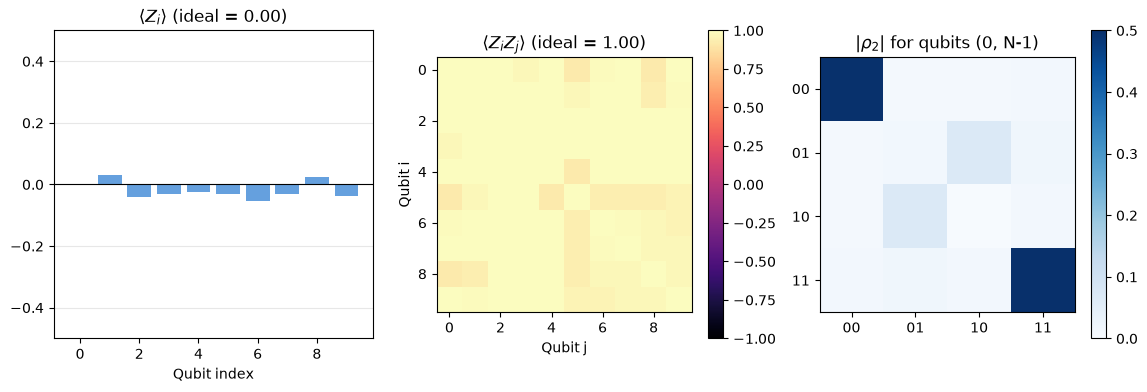

In [8]:
fig, axes = plt.subplots(
    1, 3, figsize=(14, 4), gridspec_kw={"width_ratios": [1, 1, 1]}
)

z_exact = psi.expectation_value(
    SparsePauliOp.from_sparse_list([("Z", [0], 1.0)], num_qubits)
).real  # 0.0
zz_exact = psi.expectation_value(
    SparsePauliOp.from_sparse_list([("ZZ", [0, 1], 1.0)], num_qubits)
).real  # 1.0

# <Zi>
axes[0].bar(range(num_qubits), Z_vals, color="#4a90d9", alpha=0.85)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_ylim(-0.5, 0.5)
axes[0].set_title(r"$\langle Z_i \rangle$ (ideal = %0.2f)" % z_exact)
axes[0].set_xlabel("Qubit index")
axes[0].grid(axis="y", alpha=0.3)

# <ZiZj>
im = axes[1].imshow(ZZ_mat, vmin=-1, vmax=1, cmap="magma")
plt.colorbar(im, ax=axes[1])
axes[1].set_title(r"$\langle Z_i Z_j \rangle$ (ideal = %0.2f)" % zz_exact)
axes[1].set_xlabel("Qubit j")
axes[1].set_ylabel("Qubit i")

# 2-RDM magnitude
im2 = axes[2].imshow(np.abs(rho_shadow), vmin=0, vmax=0.5, cmap="Blues")
plt.colorbar(im2, ax=axes[2])
axes[2].set_title(r"$|\rho_2|$ for qubits (0, N-1)")
axes[2].set_xticks(range(4))
axes[2].set_yticks(range(4))
axes[2].set_xticklabels(["00", "01", "10", "11"])
axes[2].set_yticklabels(["00", "01", "10", "11"])

#### Shot scaling assessment

In this tutorial, 5000 snapshots are used to estimate the observables. The shot scaling of shadow tomography is assessed by plotting the mean error of one of the estimated functions against different shot budgets. The error in the two-qubit correlator decays as $1/\sqrt{T}$ as expected for the standard statistical convergence of a mean estimator. The importance of shadow tomography is that the constant prefactor in front of $1/\sqrt{T}$ does not grow with the number of qubits for local observables, such as those examined in this tutorial.

T=  100 error = 0.1856
T=  250 error = 0.1613
T=  500 error = 0.1027
T= 1000 error = 0.0827
T= 2000 error = 0.0513
T= 5000 error = 0.0311
T=10000 error = 0.0162


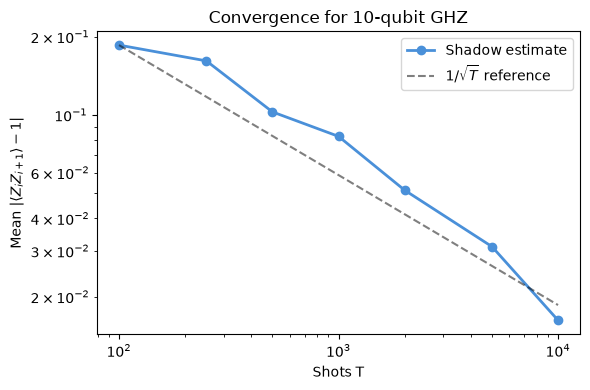

In [9]:
shot_counts = [100, 250, 500, 1000, 2000, 5000, 10000]
errors = []

for N_test in shot_counts:
    snaps = collect_shadow_snapshots(psi, N_test, num_qubits)
    zz_vals = []
    for i in range(num_qubits - 1):
        ests = []
        for bits, bases in snaps:
            e = 1.0 + 0j
            for q in range(num_qubits):
                op = "Z" if q in (i, i + 1) else "I"
                e *= shadow_estimator(op, bases[q], bits[q])
            ests.append(e.real)
        zz_vals.append(np.mean(ests))
    errors.append(float(np.mean(np.abs(np.array(zz_vals) - 1.0))))
    print(f"T={N_test:5d} error = {errors[-1]:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
T_arr = np.array(shot_counts, dtype=float)
ax.loglog(T_arr, errors, "o-", color="#4a90d9", lw=2, label="Shadow estimate")
ax.loglog(
    T_arr,
    errors[0] * np.sqrt(shot_counts[0] / T_arr),
    "k--",
    alpha=0.5,
    label=r"$1/\sqrt{T}$ reference",
)
ax.set_xlabel("Shots T")
ax.set_ylabel(r"Mean $|\langle Z_i Z_{i+1} \rangle - 1|$")
ax.set_title(f"Convergence for {num_qubits}-qubit GHZ")
ax.legend()
plt.tight_layout()
plt.show()

## Large-scale hardware example

The simulation above confirms that local Pauli shadow tomography recovers the correct observables on a noiseless statevector. Running the same protocol using 100 qubits on real hardware introduces two challenges that do not appear in simulation: gate and readout errors accumulate across the deep GHZ circuit, and the optimal qubit layout is found by searching the device's coupling graph rather than chosen by hand.

To address the first challenge, low-overhead error detection using spacetime codes [[6]](#references) is used. A small number of ancilla qubits adjacent to the GHZ tree are used as parity checks. Each ancilla is entangled with two of its GHZ neighbors before measurement, so a single bit-flip error on either neighbor flips the ancilla's outcome from `0` to `1`. Snapshots where any check ancilla reads `1` are discarded, leaving a cleaner subset from which to estimate $\langle Z_i Z_{i+1}\rangle$.

The second challenge is handled by searching over candidate GHZ tree layouts and selecting the one that maximizes parity-check coverage, that is, the fraction of circuit wires monitored by at least one check, within an acceptable increase in circuit depth.

### Steps 1-4 (performed in a single code block)

The same four-step workflow is now applied to a 100-qubit GHZ state on real quantum hardware, adding two hardware-specific features that do not arise in simulation:

- **Step 1** characterizes the backend noise (gate errors, readout errors, and T2 times) so that unreliable qubits and edges are excluded from the circuit layout.
- **Step 2** searches over possible GHZ tree layouts to find one that maximizes parity-check coverage within an acceptable circuit depth — replacing the trivial chain used in simulation.
- **Step 3** builds the shadow circuits (one per random Pauli basis), transpiles them to hardware-native gates, and submits them to the Sampler primitive with `shots=8` (each circuit produces eight independent bitstrings).
- **Step 4** postselects snapshots whose check qubits all read 0 (no detected error), then estimates $\langle Z_i Z_{i+1}\rangle$ with and without that postselection to demonstrate the improvement from error detection.

GHZ qubits: [57, 47, 67, 46, 66, 48, 45, 65, 49, 44, 64, 38, 43, 77, 29, 42, 85, 28, 56, 41, 84, 30, 27, 36, 86, 31, 21, 87, 32, 20, 88, 33, 22, 97, 89, 34, 23, 107, 78, 39, 35, 16, 106, 90, 69, 53, 19, 24, 3, 108, 105, 91, 70, 52, 15, 25, 2, 109, 104, 92, 71, 54, 51, 14, 4, 1, 110, 103, 98, 93, 58, 55, 13, 5, 0, 118, 96, 72, 59, 12, 6, 129, 102, 73, 11, 7, 128, 101, 74, 10, 8, 127, 100, 9, 126, 116, 125, 121, 124, 120] (100)
Check qubits: [68, 37, 50, 63, 83, 17, 26, 18, 117, 111, 75] (11)
Covered fraction (no idle):  0.5454545454545454
Shadow snapshots collected: 8000
Shadow snapshots kept post error-detection: 566


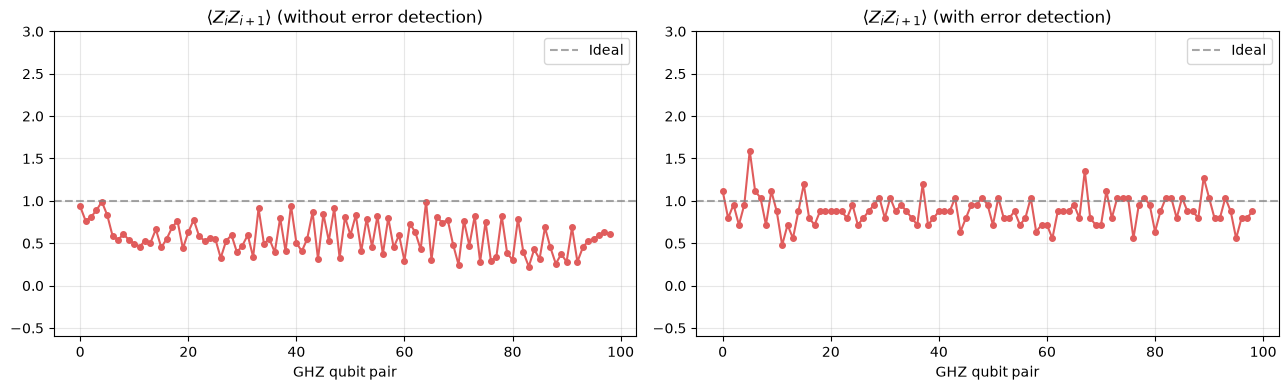

Before detection: <ZiZi+1>=  0.573749999999951
After detection: <ZiZi+1>=  0.8817377312951776
Before detection: Mean nearest-neighbor ZZ= 0.2868749999999755
After detection: Mean nearest-neighbor ZZ= 0.4408688656475888


In [10]:
# ── Step 1: Map classical inputs to a quantum problem ─────────────────────────
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=133
)
coupling_map = backend.target.build_coupling_map()
n_total = backend.num_qubits

thresh_cz, thresh_meas, thresh_t2 = 0.025, 0.15, 10
bad_edges = bad_cz(backend.target, threshold=thresh_cz)
bad_nodes_readout = bad_readout(backend.target, threshold=thresh_meas)
dead_qubits = bad_readout(backend.target, threshold=0.4)
bad_nodes = list(
    set(bad_nodes_readout)
    | set(bad_coherence(backend.target, threshold=thresh_t2))
)

# ── Step 2: Optimize for quantum hardware execution ───────────────────────────
# Search over starting qubits and random node-skip sets to find the GHZ layout
# with the best parity-check coverage within an acceptable circuit depth.
ghz_size = 100
max_skips, shuffles, max_depth_increase = 10, 200, 10
w_idle, w_gate = 0.2, 0.8

# Find the root that yields the shallowest GHZ — exclude bad_nodes from the start
best_root = None
base_depth = float("inf")
for root in range(backend.num_qubits):
    if root in bad_nodes:
        continue
    qc, ghz_qubits, _ = parallel_ghz(
        root, ghz_size, backend, bad_edges, bad_nodes
    )
    if len(ghz_qubits) != ghz_size:
        continue
    depth = qc.depth(lambda x: x.operation.num_qubits == 2)
    if depth < base_depth:
        best_root, base_depth = root, depth
if best_root is None:
    raise Exception("No qualifying GHZ root layout found. Relax error thresholds.")

qc, ghz_qubits, layers = parallel_ghz(best_root, ghz_size, backend, bad_edges, bad_nodes)

degree_two_nodes = [
    i
    for i in ghz_qubits
    if all(n in ghz_qubits for n in coupling_map.neighbors(i))
    and len(coupling_map.neighbors(i)) >= 2
]

best_covered_fraction = -1
best_qc = best_checks = best_parities = best_layers = best_ghz_qubits = None

for num_skips in range(max_skips):
    for _ in range(shuffles):
        skip_trial = list(
            rng.choice(degree_two_nodes, num_skips, replace=False)
        )
        qc, ghz_qubits, layers = parallel_ghz(
            best_root, ghz_size, backend, bad_edges, skip_trial + bad_nodes
        )
        if len(ghz_qubits) != ghz_size:
            continue
        depth = qc.depth(lambda x: x.operation.num_qubits == 2)
        checks, parities = [], []
        for ancilla, neighbors in get_low_overhead_ancillas(
            coupling_map, ghz_qubits
        ).items():
            if ancilla in dead_qubits:
                continue
            good_neighbors = [
                n
                for n in neighbors
                if [ancilla, n] not in bad_edges
                and [n, ancilla] not in bad_edges
            ]
            if len(good_neighbors) < 2:
                continue
            checks.append(ancilla)
            parities.append((good_neighbors[0], good_neighbors[1]))
            qc.cx(good_neighbors[0], ancilla)
            qc.cx(good_neighbors[1], ancilla)
        covered_fraction = weighted_coverage(
            layers=layers, parities=parities, w_idle=w_idle, w_gate=w_gate
        )
        if (
            covered_fraction > best_covered_fraction
            and depth <= base_depth + max_depth_increase
        ):
            best_covered_fraction = covered_fraction
            (
                best_qc,
                best_ghz_qubits,
                best_checks,
                best_parities,
                best_layers,
            ) = qc, ghz_qubits, checks, parities, layers

qc, ghz_qubits, checks, parities, layers = (
    best_qc,
    best_ghz_qubits,
    best_checks,
    best_parities,
    best_layers,
)
if len(ghz_qubits) != ghz_size:
    raise Exception("No GHZ found. Relax error thresholds.")

print(f"GHZ qubits: {ghz_qubits} ({len(ghz_qubits)})")
print(f"Check qubits: {checks} ({len(checks)})")
print(
    "Covered fraction (no idle): ",
    weighted_coverage(
        layers=layers, parities=parities, w_idle=0.0, w_gate=1.0
    ),
)

# ── Step 3: Execute using Qiskit primitives ───────────────────────────────────
# Build one shadow circuit per random Pauli basis, each repeated for shots_per_basis
# independent bitstrings. Transpile to hardware-native gates, then submit using the
# Sampler primitive. Each circuit yields shots_per_basis snapshots in that basis.
n_hw = 1000
shots_per_basis = 8  # multiple shots per basis circuit
shadow_circs, hw_bases = build_shadow_circuits(qc, n_hw, ghz_qubits, checks)
sampler = Sampler(backend)
sampler.options.environment.job_tags = ["TUT_STGHZS"]
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(shadow_circs)
job = sampler.run(isa_circuit, shots=shots_per_basis)
result = job.result()

# ── Step 4: Post-process and return result in desired classical format ─────────
# Filter snapshots whose check qubits all read 0 (no detected error), then
# estimate <ZiZi+1> with and without the error-detection postselection.
snapshots_hw = parse_hw_results_w_checks(result, hw_bases, ghz_qubits, checks)
snapshots_kept = [
    (ghz_bits, check_bits, bases)
    for (ghz_bits, check_bits, bases) in snapshots_hw
    if all(b == 0 for b in check_bits)
]
snapshots_kept_adapted = [
    (adapt_to_flat_bits(ghz_bits, ghz_qubits, n_total), bases)
    for (ghz_bits, check_bits, bases) in snapshots_kept
]
snapshots_hw_adapted = [
    (adapt_to_flat_bits(ghz_bits, ghz_qubits, n_total), bases)
    for (ghz_bits, check_bits, bases) in snapshots_hw
]

print("Shadow snapshots collected:", len(snapshots_hw))
print("Shadow snapshots kept post error-detection:", len(snapshots_kept))

n_groups = min(5, len(snapshots_kept))  # groups for median-of-means
ZZ_hw = estimate_zz_nn_hw(snapshots_hw_adapted, ghz_qubits, n_total, n_groups)
ZZ_kept = estimate_zz_nn_hw(
    snapshots_kept_adapted, ghz_qubits, n_total, n_groups
)

# Plot <ZiZi+1> before and after error detection
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ZZ_hw, "o-", color="#e05c5c", markersize=4)
axes[0].axhline(1.0, color="gray", ls="--", alpha=0.7, label="Ideal")
axes[0].set_ylim(-0.6, 3.0)
axes[0].set_title(r"$\langle Z_i Z_{i+1} \rangle$ (without error detection)")
axes[0].set_xlabel("GHZ qubit pair")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ZZ_kept, "o-", color="#e05c5c", markersize=4)
axes[1].axhline(1.0, color="gray", ls="--", alpha=0.7, label="Ideal")
axes[1].set_ylim(-0.6, 3.0)
axes[1].set_title(r"$\langle Z_i Z_{i+1} \rangle$ (with error detection)")
axes[1].set_xlabel("GHZ qubit pair")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Before detection: <ZiZi+1>= ", float(np.average(ZZ_hw)))
print("After detection: <ZiZi+1>= ", float(np.average(ZZ_kept)))
print(
    "Before detection: Mean nearest-neighbor ZZ=",
    float(0.5 * np.mean(ZZ_hw)),
)
print(
    "After detection: Mean nearest-neighbor ZZ=",
    float(0.5 * np.mean(ZZ_kept)),
)

#### Interpret the results

The two plots show $\langle Z_i Z_{i+1}\rangle$ estimated from shadow tomography for each neighboring qubit pair in the 100-qubit GHZ chain, before and after postselecting on the parity checks.

For an ideal GHZ state, all nearest-neighbor correlators equal $1$. On hardware, noise depresses the raw estimates and introduces qubit-to-qubit scatter. After error detection, snapshots in which at least one detectable error occurred are removed, and the remaining estimates are pulled closer to $1$ with reduced variance, which is consistent with a cleaner effective state.

The improvement after error detection is consistent with the checks detecting real errors.

## Next steps
If you found this work interesting, you might be interested in the following material:
<Admonition type="tip" title="Recommendations">
- [General formulation of quantum information](/learning/courses/general-formulation-of-quantum-information)
- [Low overhead error detection using spacetime codes tutorial](/docs/tutorials/ghz-spacetime-codes)
- [Qiskit Paulice addon API documentation](/docs/api/qiskit-addon-paulice)
</Admonition>

## References

- [1] Huang, H. Y., Kueng, R., & Preskill, J. (2020). [Predicting many properties of a quantum system from very few measurements](https://www.nature.com/articles/s41567-020-0932-7). *Nature Physics*, 16, 1050–1057.
- [2] Zhao, A., Rubin, N. C., & Miyake, A. (2021). [Fermionic partial tomography via classical shadows](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.127.110504). *Phys. Rev. Lett.*, 127, 110504.
- [3] Low, G. H. (2022). [Classical shadows of fermions with particle number symmetry](https://arxiv.org/abs/2208.08964). *arXiv:2208.08964*.
- [4] Bertoni, C., Haferkamp, J., Hinsche, M. et al. (2024). [Shallow Shadows: Expectation Estimation Using Low-Depth Random Clifford Circuits](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.133.020602). *Phys. Rev. Lett.*, 133, 020602.
- [5] Hu, H.-Y., Gu, A., Majumder, S. et al. (2025). [Demonstration of robust and efficient quantum property learning with shallow shadows](https://doi.org/10.1038/s41467-025-57349-w). *Nature Communications*, 16, 2943.
- [6] Martiel, S. & Javadi-Abhari, A. (2025). [Low-overhead error detection with spacetime codes](https://arxiv.org/abs/2504.15725). *arXiv:2504.15725*.

© IBM Corp. 2026